In [1]:
import clip
# 查看可用的CLIP模型
clip.available_models()  # ['RN50', 'RN101', 'RN50x4', 'RN50x16', 'RN50x64', 'ViT-B/32', 'ViT-B/16', 'ViT-L/14', 'ViT-L/14@336px']

['RN50',
 'RN101',
 'RN50x4',
 'RN50x16',
 'RN50x64',
 'ViT-B/32',
 'ViT-B/16',
 'ViT-L/14',
 'ViT-L/14@336px']

原始图像： (800, 1200)


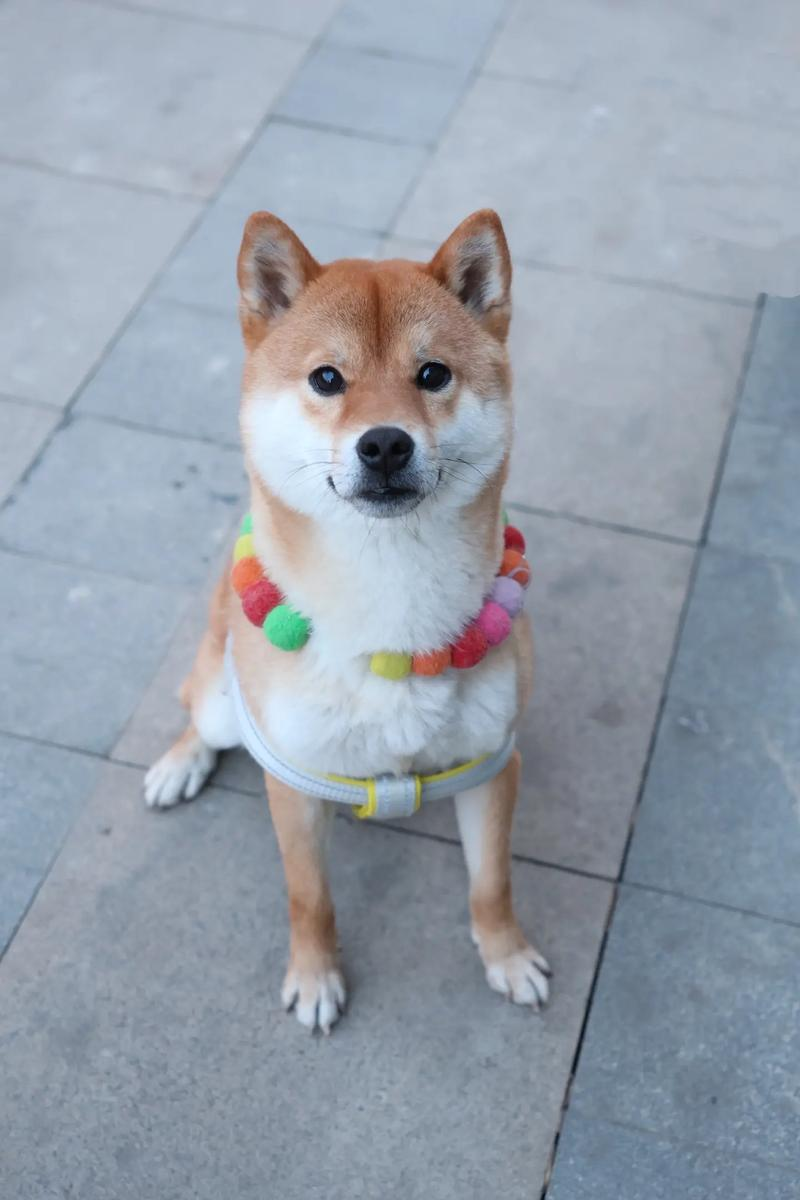

预处理后图像形状： torch.Size([1, 3, 224, 224])
预测概率：
a photo of a dog: 0.9863
a photo of a cat: 0.0010
a photo of a car: 0.0002
a photo of a landscape: 0.0001
a photo of a person: 0.0124

最可能的结果: a photo of a dog (概率: 0.9863)


In [ ]:
import torch
import clip
from PIL import Image

# 加载模型和预处理函数
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

# 在jupyter notebook中加载并显示原始图像"dog.jpg
from IPython.display import display
original_image = Image.open("dog.jpg")
print("原始图像：", original_image.size)
display(original_image)

# 预处理图像
image = preprocess(original_image).unsqueeze(0).to(device)
print("预处理后图像形状：", image.shape)

# 定义候选文本类别
text_descriptions = [
    "a photo of a dog", 
    "a photo of a cat",
    "a photo of a car",
    "a photo of a landscape",
    "a photo of a person"
]

# 对文本进行编码
text = clip.tokenize(text_descriptions).to(device)

# 进行推理
with torch.no_grad():
    # 编码图像和文本
    image_features = model.encode_image(image)
    text_features = model.encode_text(text)
    
    # 计算相似度
    logits_per_image, logits_per_text = model(image, text)
    probs = logits_per_image.softmax(dim=-1).cpu().numpy()

# 输出结果
print("预测概率：")
for desc, prob in zip(text_descriptions, probs[0]):
    print(f"{desc}: {prob:.4f}")

# 找到最可能的类别
best_match_idx = probs[0].argmax()
print(f"\n最可能的结果: {text_descriptions[best_match_idx]} (概率: {probs[0][best_match_idx]:.4f})")

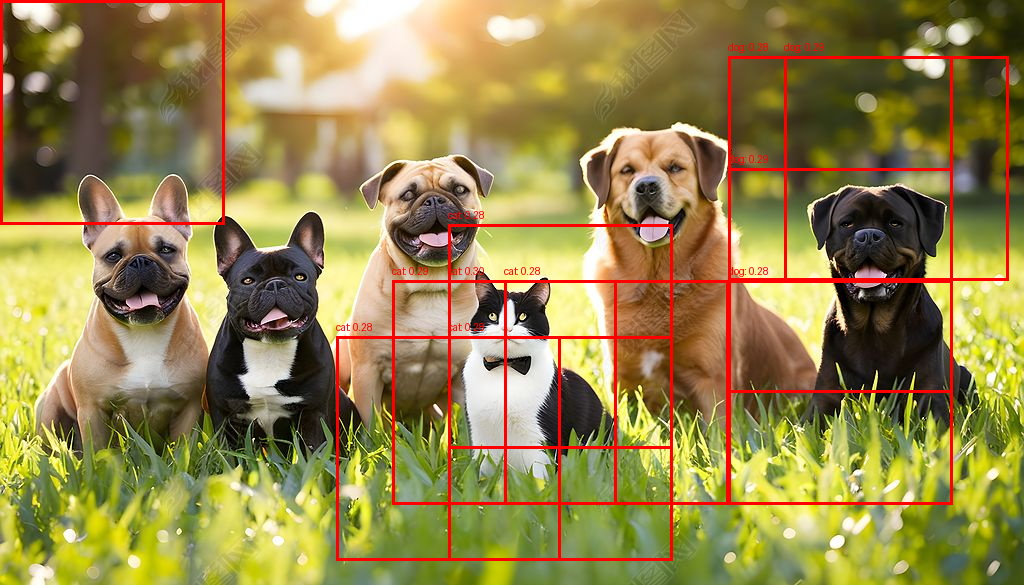

In [30]:
import torch
import clip
from PIL import Image, ImageDraw
import numpy as np

class ZeroShotObjectDetector:
    def __init__(self, model_name="ViT-B/32"):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.model, self.preprocess = clip.load(model_name, device=self.device)
    
    def detect_objects(self, image_path, object_classes, confidence_threshold=0.2):
        """
        零样本目标检测
        object_classes: 要检测的物体类别列表，如 ['dog', 'cat', 'car']
        """
        # 加载原始图像
        original_image = Image.open(image_path)
        width, height = original_image.size
        
        # 创建滑动窗口
        window_size = 224
        stride = 56
        
        detections = []
        
        # 滑动窗口遍历图像
        for y in range(0, height - window_size + 1, stride):
            for x in range(0, width - window_size + 1, stride):
                # 裁剪窗口
                crop = original_image.crop((x, y, x + window_size, y + window_size))
                
                # 预处理
                image_input = self.preprocess(crop).unsqueeze(0).to(self.device)
                
                # 准备文本提示
                text_descriptions = [f"a photo of a {cls}" for cls in object_classes]
                text_input = clip.tokenize(text_descriptions).to(self.device)
                
                # 计算相似度
                with torch.no_grad():
                    image_features = self.model.encode_image(image_input)
                    text_features = self.model.encode_text(text_input)
                    
                    similarity = torch.cosine_similarity(
                        image_features, text_features
                    )
                    max_similarity, best_class_idx = similarity.max(0)
                    confidence = max_similarity.item()
                
                # 如果置信度超过阈值，记录检测结果
                if confidence > confidence_threshold:
                    detections.append({
                        'bbox': [x, y, x + window_size, y + window_size],
                        'class': object_classes[best_class_idx],
                        'confidence': confidence
                    })
        
        return detections, original_image
    
    def draw_detections(self, image, detections):
        """在图像上绘制检测结果"""
        draw = ImageDraw.Draw(image)
        
        for detection in detections:
            bbox = detection['bbox']
            class_name = detection['class']
            confidence = detection['confidence']
            
            # 绘制边界框
            draw.rectangle(bbox, outline="red", width=3)
            
            # 绘制标签
            label = f"{class_name}: {confidence:.2f}"
            draw.text((bbox[0], bbox[1] - 15), label, fill="red")
        
        return image

# 使用示例
detector = ZeroShotObjectDetector()
detections, original_image = detector.detect_objects(
    "dog&cat.jpg", 
    object_classes=["dog", "cat"],
    confidence_threshold=0.28
)

# 绘制结果
result_image = detector.draw_detections(original_image, detections)
display(result_image)
#result_image.save("detection_result.jpg")